In [15]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.metrics import accuracy_score, roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix

# Generate dataset

In [81]:
X, y = make_classification( n_samples=2502,
                            random_state=259202,
                            n_features=2,
                            n_informative=2,
                            n_redundant=0,
                            n_repeated=0,
                            class_sep=2)
Xm, ym = make_moons(n_samples=2502, random_state=259202)
Xb ,yb = make_blobs(n_samples=2502, random_state=259202, n_features=2, centers=5, cluster_std=0.8)

In [82]:
X.shape, y.shape, Xm.shape, ym.shape, Xb.shape, yb.shape

((2502, 2), (2502,), (2502, 2), (2502,), (2502, 2), (2502,))

In [83]:
print(set(yb))
yb = np.where(yb == 3, 0, yb)
yb = np.where(yb == 4, 1, yb)
yb = np.where(yb == 5, 2, yb)
print(set(yb))

{0, 1, 2, 3, 4}
{0, 1, 2}


In [84]:
def plot_data(X,y, title=""):
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
    plt.title(title)
    plt.show()

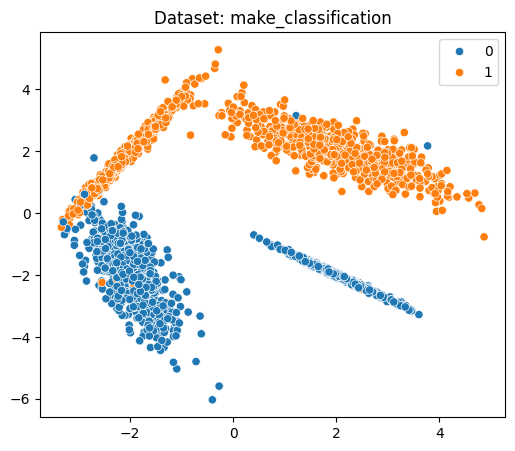

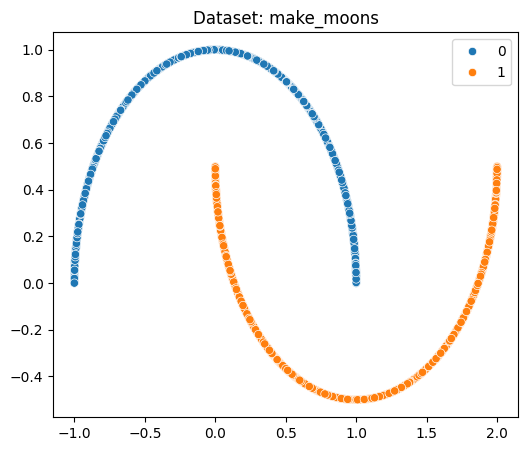

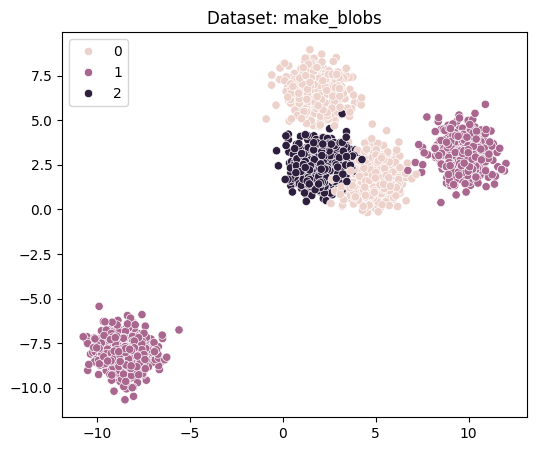

In [85]:
plot_data(X,y,"Dataset: make_classification")
plot_data(Xm,ym,"Dataset: make_moons")
plot_data(Xb,yb,"Dataset: make_blobs")

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=295202)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, random_state=295202)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, random_state=295202)

In [87]:
def plot_decision_boundary(X, y, model, title=""):
    h = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    pts = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(pts)

    # reshape the result back into the grid
    Z = Z.reshape(xx.shape)

    # plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3)
    
    # plot decision line boundary
    plt.contour(xx, yy, Z, colors='k', linewidths=1)
    
    # data points
    scatter = plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
    
    plt.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
    plt.title(title)
    plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.show()

# Implemented Decision Tree Classifier

No need for normalization - there are ifs.

In [88]:
class TreeNode:
    """Node of a decision tree"""
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None,*, value=None):
        self.feature_idx = feature_idx # index of the feature to split on
        self.threshold = threshold # threshold value to split on
        self.left = left # left child node
        self.right = right # right child node
        self.value = value # class label if leaf node, the * is forcing the use of keyword arguments for value
        
    def is_leaf(self):
        return self.value is not None

In [89]:
class DecisionTree:
    """Decision Tree Classifier with entropy"""
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.root = None
    
    def fit(self, X, y):
        self.root = self._grow_tree(X,y, depth=0)
        return self
        
    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        
        # stopping criteria
        if (self.max_depth is not None and depth >= self.max_depth) or n_labels == 1:
            leaf_value = self._most_common_label(y)
            return TreeNode(value=leaf_value)
        
        # find best split
        best_feature, best_thresh = self._best_split(X, y, n_features)
        
        # handle edge case - no split found
        if best_feature is None or best_thresh is None:
            leaf_value = self._most_common_label(y)
            return TreeNode(value=leaf_value)
        
        # create child nodes
        left_idxs, right_idxs = self._split(X[:, best_feature] ,best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth+1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth+1)
        
        return TreeNode(best_feature, best_thresh, left, right)
        
    def _best_split(self, X, y, n_features):
        best_gain = -1
        split_idx, split_thrs = None, None
        
        for feat_idx in range(n_features):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            
            for thr in thresholds:
                # calculate IG
                gain = self._information_gain(y, X_column, thr)
                
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thrs = thr
                    
        return split_idx, split_thrs
    
    def _information_gain(self, y, X_column, threshold):
        # parent entropy
        parent_entropy = self._entropy(y)
        
        # create children
        left_idxs, right_idxs = self._split(X_column, threshold)
        
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0
        
        # calculate the weighted avg entropy of children
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l/n) * e_l + (n_r/n) * e_r        
        
        # calculate IG
        information_gain = parent_entropy - child_entropy
        
        return information_gain
        
    def _split(self, X_column, split_threshold):
        left_idxs = np.argwhere(X_column <= split_threshold).flatten()
        right_idxs = np.argwhere(X_column > split_threshold).flatten()
        return left_idxs, right_idxs
        
    def _entropy(self, y):
        # np.bincount([1,2,3,1,2]) -> [0, 2, 2, 1]
        hist = np.bincount(y) # on each index is the count of the index value in y
        ps = hist / len(y) # p(x)
        return -np.sum([ p * np.log(p) if p > 0 else 0 for p in ps ])
        
        
    def _most_common_label(self, y):
        counter = Counter(y)
        value = counter.most_common(1)[0][0]
        return value
    
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])
    
    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value
        
        if x[node.feature_idx] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

In [90]:
datasets = {
    'classification': (X_train, y_train, X_test, y_test),
    'moons': (Xm_train, ym_train, Xm_test, ym_test),
    'blobs': (Xb_train, yb_train, Xb_test, yb_test)
}

all_results = []
for ds_name, (X_tr, y_tr, X_te, y_te) in datasets.items():

    n_features = X_tr.shape[1]
    n_clusters = len(np.unique(y_tr))
    depths = [None, n_features, n_clusters]
    
    for depth in set(depths):
        clf = DecisionTree(max_depth=depth)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        acc = accuracy_score(y_te, y_pred)
        
        all_results.append({
            'dataset': ds_name,
            'depth': depth,
            'accuracy': acc,
            'model': clf
        })

results_impl_df = pd.DataFrame(all_results)

In [91]:
results_impl_df

,dataset,depth,accuracy,model
0,classification,NaN,0.976038,<__main__.DecisionTree object at 0x0000029E43D...
1,classification,2.0,0.992013,<__main__.DecisionTree object at 0x0000029E43B...
2,moons,NaN,0.995208,<__main__.DecisionTree object at 0x0000029E43F...
3,moons,2.0,0.816294,<__main__.DecisionTree object at 0x0000029E3CB...
4,blobs,NaN,0.966454,<__main__.DecisionTree object at 0x0000029E438...
5,blobs,2.0,0.797125,<__main__.DecisionTree object at 0x0000029E43D...
6,blobs,3.0,0.797125,<__main__.DecisionTree object at 0x0000029E43B...


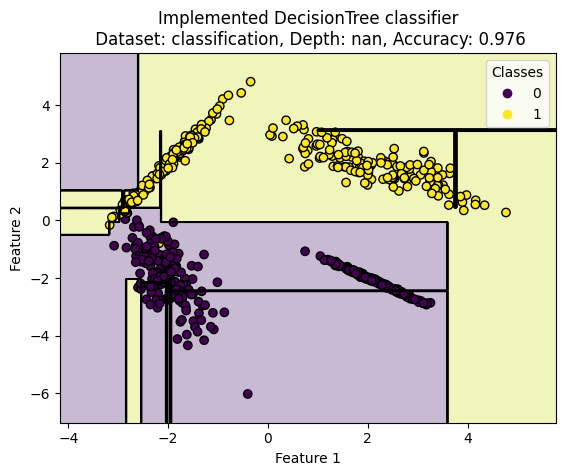

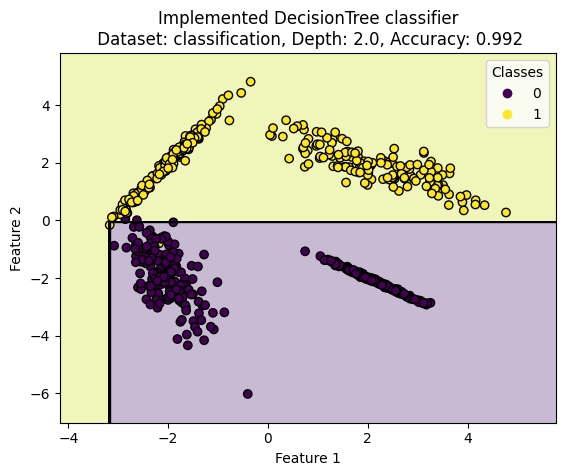

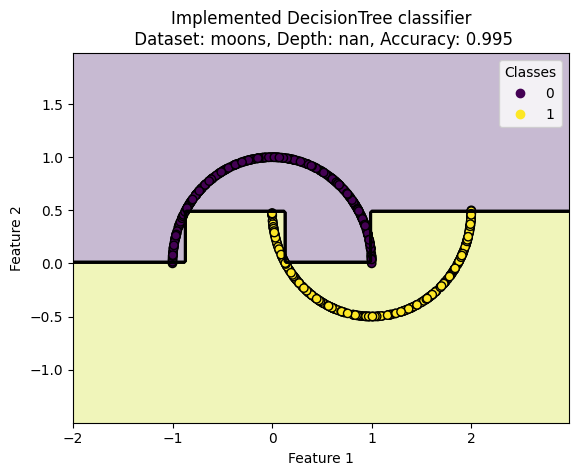

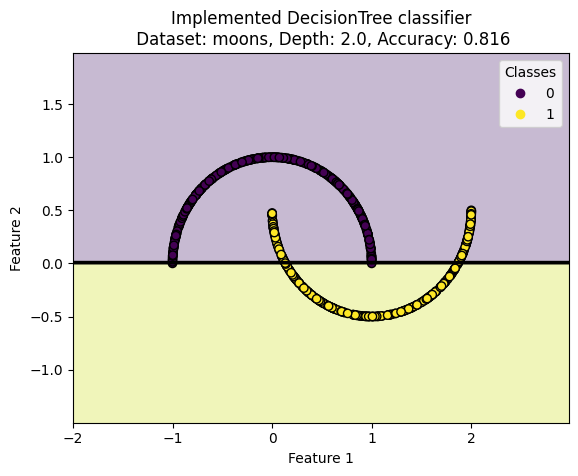

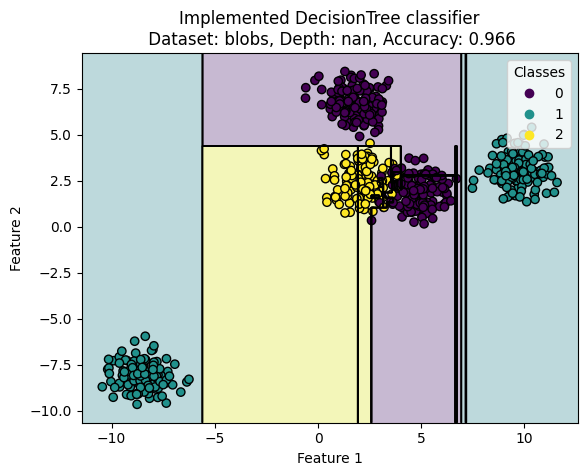

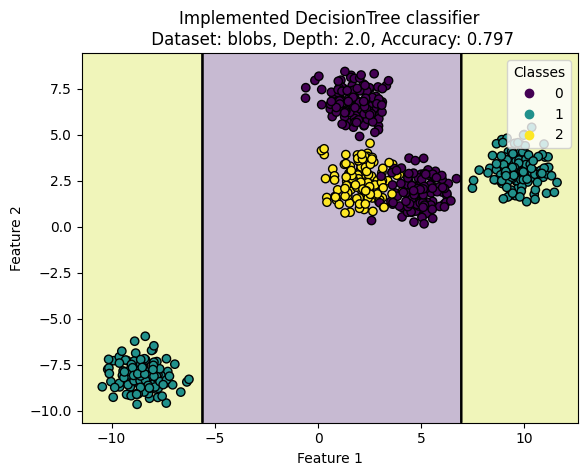

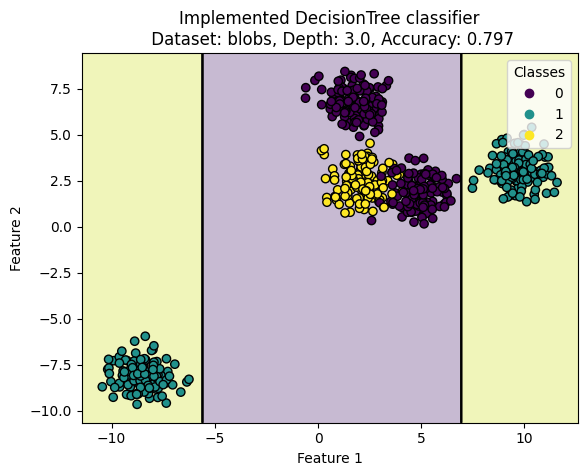

In [92]:
for _, result in results_impl_df.iterrows():
    ds_name = result['dataset']
    depth = result['depth']
    model = result['model']
    _, _, X_te, y_te = datasets[ds_name]
    
    title = f"Implemented DecisionTree classifier\n Dataset: {ds_name}, Depth: {depth}, Accuracy: {result['accuracy']:.3f}"
    
    plot_decision_boundary(X_te, y_te, model, title=title)

# Sklearn DecisionTreeClassifier

In [101]:
datasets = {
    'classification': (X_train, y_train, X_test, y_test),
    'moons': (Xm_train, ym_train, Xm_test, ym_test),
    'blobs': (Xb_train, yb_train, Xb_test, yb_test)
}

all_results = []
for ds_name, (X_tr, y_tr, X_te, y_te) in datasets.items():

    n_features = X_tr.shape[1]
    n_clusters = len(np.unique(y_tr))
    depths = [None, n_features, n_clusters]
    
    for depth in set(depths):
        clf = DecisionTreeClassifier(criterion='entropy', max_depth=depth)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        acc = accuracy_score(y_te, y_pred)
        
        all_results.append({
            'dataset': ds_name,
            'depth': depth,
            'accuracy': acc,
            'model': clf
        })

results_df = pd.DataFrame(all_results)

In [102]:
results_df

,dataset,depth,accuracy,model
0,classification,NaN,0.974441,DecisionTreeClassifier(criterion='entropy')
1,classification,2.0,0.993610,"DecisionTreeClassifier(criterion='entropy', ma..."
2,moons,NaN,0.996805,DecisionTreeClassifier(criterion='entropy')
3,moons,2.0,0.816294,"DecisionTreeClassifier(criterion='entropy', ma..."
4,blobs,NaN,0.966454,DecisionTreeClassifier(criterion='entropy')
5,blobs,2.0,0.797125,"DecisionTreeClassifier(criterion='entropy', ma..."
6,blobs,3.0,0.797125,"DecisionTreeClassifier(criterion='entropy', ma..."


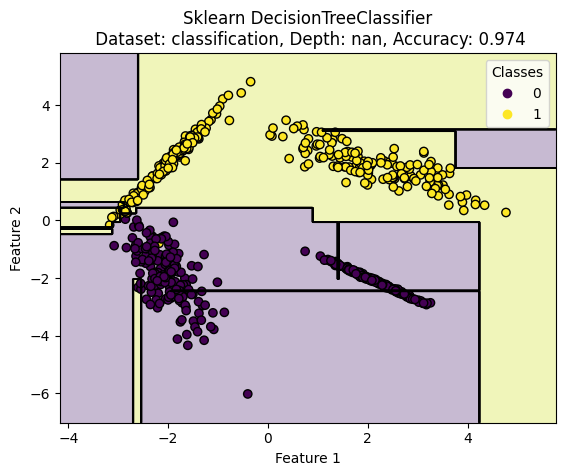

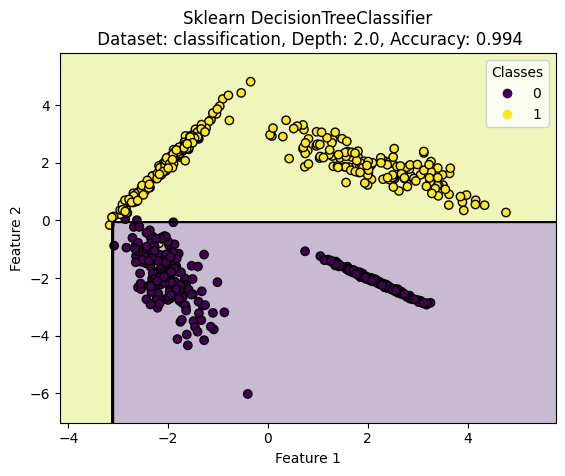

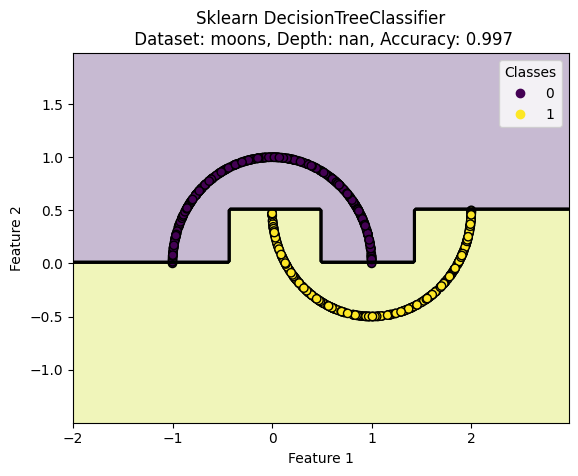

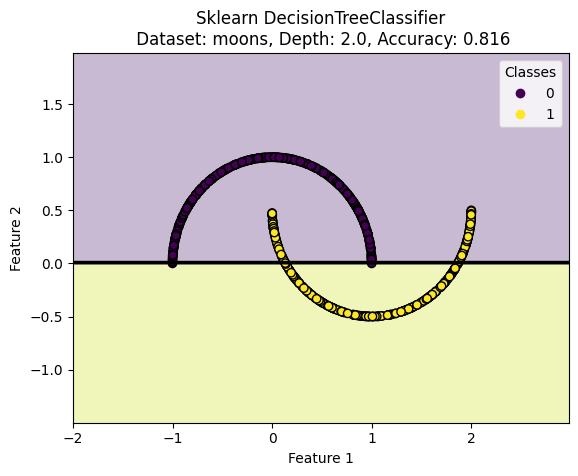

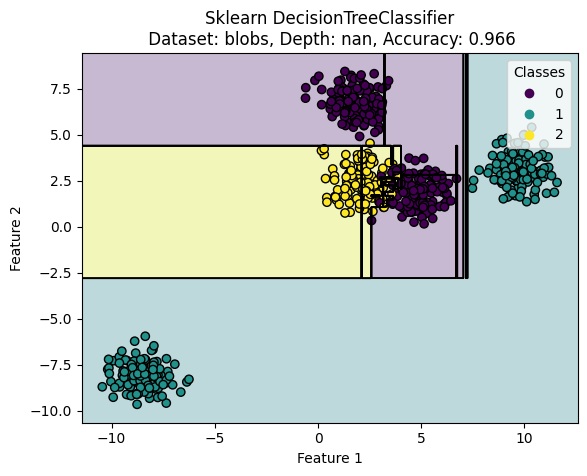

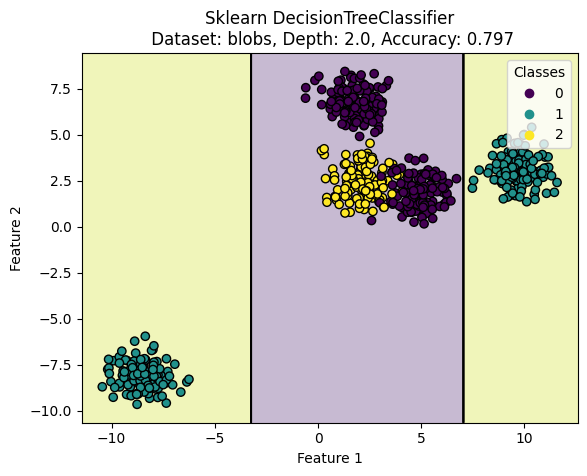

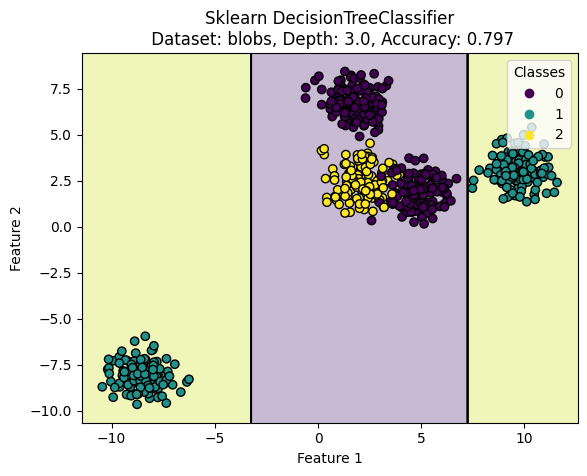

In [103]:
for _, result in results_df.iterrows():
    ds_name = result['dataset']
    depth = result['depth']
    model = result['model']
    _, _, X_te, y_te = datasets[ds_name]
    
    title = f"Sklearn DecisionTreeClassifier\n Dataset: {ds_name}, Depth: {depth}, Accuracy: {result['accuracy']:.3f}"
    
    plot_decision_boundary(X_te, y_te, model, title=title)

In [104]:
results_impl_df

,dataset,depth,accuracy,model
0,classification,NaN,0.976038,<__main__.DecisionTree object at 0x0000029E43D...
1,classification,2.0,0.992013,<__main__.DecisionTree object at 0x0000029E43B...
2,moons,NaN,0.995208,<__main__.DecisionTree object at 0x0000029E43F...
3,moons,2.0,0.816294,<__main__.DecisionTree object at 0x0000029E3CB...
4,blobs,NaN,0.966454,<__main__.DecisionTree object at 0x0000029E438...
5,blobs,2.0,0.797125,<__main__.DecisionTree object at 0x0000029E43D...
6,blobs,3.0,0.797125,<__main__.DecisionTree object at 0x0000029E43B...


In [105]:
results_df

,dataset,depth,accuracy,model
0,classification,NaN,0.974441,DecisionTreeClassifier(criterion='entropy')
1,classification,2.0,0.993610,"DecisionTreeClassifier(criterion='entropy', ma..."
2,moons,NaN,0.996805,DecisionTreeClassifier(criterion='entropy')
3,moons,2.0,0.816294,"DecisionTreeClassifier(criterion='entropy', ma..."
4,blobs,NaN,0.966454,DecisionTreeClassifier(criterion='entropy')
5,blobs,2.0,0.797125,"DecisionTreeClassifier(criterion='entropy', ma..."
6,blobs,3.0,0.797125,"DecisionTreeClassifier(criterion='entropy', ma..."
